## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import types
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pylab as pl
import numpy as np
import scipy as sp
from scipy import stats
import yaml

from caa_model.config import *
from caa_model.models import base_model, disp_classic, sisp_classic, sisp_var_rbound, disp_staggered
from caa_model.models.results import *
from caa_model.models.base_model import BaseDDM
from caa_model.models.disp_classic import DISPClassicDDM
from caa_model.models.sisp_classic import SISPClassicDDM
from caa_model.models.sisp_var_rbound import SISPVarRBoundDDM
from caa_model.models.disp_staggered import DISPStaggeredDDM

## Setup

In [2]:
data = base_model.DATA

caa_cfg = CAAConfig(
    delta_t=0.025,
    nr_ssteps=8192,
    nr_samples=10000,
    max_t=8.0,
)

def display_comparison(evals: list[ModelEvaluation]):
    """Renders a side-by-side comparison Markdown table for multiple ModelEvaluations."""
    methods = " | ".join([f"`{e.method.upper()}`" for e in evals])
    align = " | ".join(["---:"] * len(evals))
    
    trials = " | ".join([f"{e.n_trials:,}" for e in evals])
    params = " | ".join([f"{e.n_params}" for e in evals])
    nll    = " | ".join([f"{e.nll:.2f}" for e in evals])
    aic    = " | ".join([f"**{e.aic:.2f}**" for e in evals])
    bic    = " | ".join([f"**{e.bic:.2f}**" for e in evals])

    md_table = f"""
### Model Evaluation Comparison

| Metric | {methods} |
| :--- | {align} |
| **Trials ($N$)** | {trials} |
| **Parameters ($k$)** | {params} |
| **Negative Log-Likelihood** | {nll} |
| **AIC** | {aic} |
| **BIC** | {bic} |
"""
    display(Markdown(md_table))

def fit_methods(model, methods, **kwargs):
    return {m: model.fit(method=m, **kwargs) for m in methods}

methods = ["qmle", "qmpe"]

In [3]:
def compute_gof_lure(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
    """Overrides the base loss function to ONLY compute loss for Lures."""
    try:
        target_params, lure_params = self.split_params(model_params)

        # Only extract the new (lure) data
        new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

        # Compute GOF ONLY for the lures
        gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

        if pl.isnan(gof_lure) or pl.isinf(gof_lure):
            return 1e9
        return gof_lure
    except Exception:
        return 1e9


def compute_gof_target(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
    """Overrides the base loss function to ONLY compute loss for Targets."""
    try:
        target_params, lure_params = self.split_params(model_params)

        # Only extract the old (target) data
        old_data = [data.rem_hit.rt, data.know_hit.rt, data.miss.rt, data.rem_hit.conf, data.know_hit.conf]

        # Compute GOF ONLY for the targets
        gof_target = self.compute_model_gof(target_params, *old_data, method=method, use_chisq=use_chisq)

        if pl.isnan(gof_target) or pl.isinf(gof_target):
            return 1e9
        return gof_target
    except Exception:
        return 1e9


## RT Data

In [4]:
# Assuming 3 confidence levels (0, 1, 2)
conf_levels = [0, 1, 2]

print("=== TARGETS (Old Words) ===")
for conf in conf_levels:
    rem_count = len(data.rem_hit.rt[data.rem_hit.conf == conf])
    know_count = len(data.know_hit.rt[data.know_hit.conf == conf])
    print(f"Conf {conf} | Remember: {rem_count:<4} | Know: {know_count:<4}")

print(f"Misses: {len(data.miss.rt)}")


print("\n=== LURES (New Words) ===")
for conf in conf_levels:
    rem_fa_count = len(data.rem_fa.rt[data.rem_fa.conf == conf])
    know_fa_count = len(data.know_fa.rt[data.know_fa.conf == conf])
    print(f"Conf {conf} | Rem FA:   {rem_fa_count:<4} | Know FA: {know_fa_count:<4}")

print(f"Correct Rejections: {len(data.CR.rt)}")

=== TARGETS (Old Words) ===
Conf 0 | Remember: 23   | Know: 47  
Conf 1 | Remember: 362  | Know: 431 
Conf 2 | Remember: 917  | Know: 526 
Misses: 1543

=== LURES (New Words) ===
Conf 0 | Rem FA:   28   | Know FA: 59  
Conf 1 | Rem FA:   228  | Know FA: 356 
Conf 2 | Rem FA:   195  | Know FA: 164 
Correct Rejections: 2856


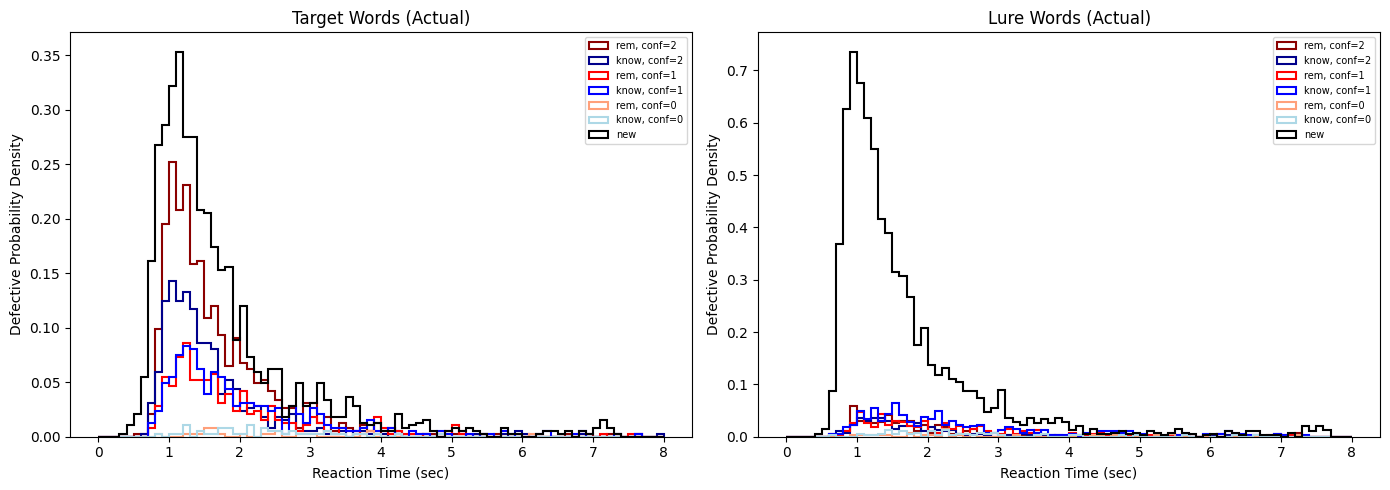

In [5]:
# Calculate total N for Targets and Lures
N_target = len(data.rem_hit.rt) + len(data.know_hit.rt) + len(data.miss.rt)
N_lure = len(data.rem_fa.rt) + len(data.know_fa.rt) + len(data.CR.rt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]
conf_vals = [2, 1, 0]

colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

# Define fixed bins (e.g., 50ms intervals) up to your model's max_t
bin_width = 0.1
bins = np.arange(0, caa_cfg.max_t + bin_width, bin_width)


def plot_empirical_hist(ax, rt_data, total_N, color, label):
    """Plots true data frequencies as step histograms without Gaussian smoothing artifacts."""
    if len(rt_data) > 0:
        # Weight each trial so the area under all curves combined equals 1.0
        weights = np.ones_like(rt_data) / (total_N * bin_width)

        # histtype='step' draws just the outline, preventing visual clutter
        ax.hist(rt_data, bins=bins, weights=weights, color=color, label=label, histtype="step", linewidth=1.5)


# --- Target Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    rt_subset_rem = data.rem_hit.rt[data.rem_hit.conf == conf_val]
    plot_empirical_hist(axes[0], rt_subset_rem, N_target, colors_rem[i], f"rem, {confidence_labels[i]}")

    rt_subset_know = data.know_hit.rt[data.know_hit.conf == conf_val]
    plot_empirical_hist(axes[0], rt_subset_know, N_target, colors_know[i], f"know, {confidence_labels[i]}")

plot_empirical_hist(axes[0], data.miss.rt, N_target, "black", "new")

axes[0].set_title("Target Words (Actual)")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("Defective Probability Density")
axes[0].legend(fontsize=7)

# --- Lure Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    rt_subset_rem = data.rem_fa.rt[data.rem_fa.conf == conf_val]
    plot_empirical_hist(axes[1], rt_subset_rem, N_lure, colors_rem[i], f"rem, {confidence_labels[i]}")

    rt_subset_know = data.know_fa.rt[data.know_fa.conf == conf_val]
    plot_empirical_hist(axes[1], rt_subset_know, N_lure, colors_know[i], f"know, {confidence_labels[i]}")

plot_empirical_hist(axes[1], data.CR.rt, N_lure, "black", "new")

axes[1].set_title("Lure Words (Actual)")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("Defective Probability Density")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Lure Only

### SISP Var R Bound

In [ ]:
class SISPVarRBoundLuresOnly(SISPVarRBoundDDM):
    Params = SISPVarRBoundDDM.Params

    def compute_gof_all(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
        """Overrides the base loss function to ONLY compute loss for Lures."""
        try:
            target_params, lure_params = self.split_params(model_params)

            # Only extract the new (lure) data
            new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

            # Compute GOF ONLY for the lures
            gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

            if pl.isnan(gof_lure) or pl.isinf(gof_lure):
                return 1e9
            return gof_lure
        except Exception:
            return 1e9


sisp_var_rbound_lure_model = SISPVarRBoundLuresOnly(
    config=caa_cfg,
    nr_threads=1,
)

original_bounds = sisp_var_rbound.param_bounds
locked_lower = original_bounds[0]
locked_upper = original_bounds[1]._replace(
    mu_t=locked_lower.mu_t,
    z0_t=locked_lower.z0_t,
)
param_bounds = (locked_lower, locked_upper)

n_params = 9
n_trials = (
    len(data.CR.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

# Optimize over entire data
# sisp_var_rbound_lure_opt = fit_methods(
#     sisp_var_rbound_lure_model,
#     methods,
#     param_bounds=param_bounds,
#     nr_workers=7,
# )

# Non-negative
# sisp_var_rbound_lure_opt = {'qmle': SISPVarRBoundLuresOnly.Params(c=np.float64(1.3455311204135363), mu_t=np.float64(0.0), mu_l=np.float64(0.0001268645515426492), d=np.float64(0.4466774254451723), tc_bound=np.float64(0.003960911913241438), r_bound_offset=np.float64(1.8430054654365686), sigma_r_bound=np.float64(1.981052602886464), z0_t=np.float64(-2.0), z0_l=np.float64(-0.3943012919234732), t_post=np.float64(0.5537083302621592), t0=np.float64(0.6875705071568965)),
#  'qmpe': SISPVarRBoundLuresOnly.Params(c=np.float64(1.3099469833754376), mu_t=np.float64(0.0), mu_l=np.float64(1.280330073860636e-05), d=np.float64(0.4555691055019462), tc_bound=np.float64(0.023004083069981723), r_bound_offset=np.float64(1.7520209072381943), sigma_r_bound=np.float64(1.9638993641432692), z0_t=np.float64(-2.0), z0_l=np.float64(-0.36976364147587454), t_post=np.float64(0.5415542780618259), t0=np.float64(0.6912798108901295))}

# Negative
sisp_var_rbound_lure_opt = {'qmle': SISPVarRBoundLuresOnly.Params(c=np.float64(1.0757657843123074), mu_t=np.float64(-2.0), mu_l=np.float64(-0.253844409401231), d=np.float64(0.39049761431022456), tc_bound=np.float64(0.08421599717056705), r_bound_offset=np.float64(1.3911097452533763), sigma_r_bound=np.float64(1.918853041570972), z0_t=np.float64(-2.0), z0_l=np.float64(-0.2091904762121095), t_post=np.float64(0.39212929143515907), t0=np.float64(0.5909796710604172)),
 'qmpe': SISPVarRBoundLuresOnly.Params(c=np.float64(1.1743284632358724), mu_t=np.float64(-2.0), mu_l=np.float64(-0.2678776052677323), d=np.float64(0.45308668720094064), tc_bound=np.float64(0.020466600158162564), r_bound_offset=np.float64(1.5127048424485048), sigma_r_bound=np.float64(1.9874358924394764), z0_t=np.float64(-2.0), z0_l=np.float64(-0.23071586908336306), t_post=np.float64(0.4387761148167658), t0=np.float64(0.6552801580313385))}

method = "qmpe"
params_est = sisp_var_rbound_lure_opt[method]

differential_evolution step 1: f(x)= 579.5420839455528
differential_evolution step 2: f(x)= 579.3839454469198
differential_evolution step 3: f(x)= 579.3839454469198
differential_evolution step 4: f(x)= 579.3839454469198
differential_evolution step 5: f(x)= 555.9750054091346
differential_evolution step 6: f(x)= 555.9750054091346
differential_evolution step 7: f(x)= 405.41038937102894
differential_evolution step 8: f(x)= 288.43468348083843
differential_evolution step 9: f(x)= 237.10005699836984
differential_evolution step 10: f(x)= 237.10005699836984
differential_evolution step 11: f(x)= 237.10005699836984
differential_evolution step 12: f(x)= 237.10005699836984
differential_evolution step 13: f(x)= 205.9476232137713
differential_evolution step 14: f(x)= 205.9476232137713
differential_evolution step 15: f(x)= 205.56845835033164
differential_evolution step 16: f(x)= 205.56845835033164
differential_evolution step 17: f(x)= 205.56845835033164
differential_evolution step 18: f(x)= 186.990217


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 3,886 | 3,886 | 3,886 |
| **Parameters ($k$)** | 9 | 9 | 9 |
| **Negative Log-Likelihood** | 160.09 | 166.35 | 8200.91 |
| **AIC** | **338.19** | **350.69** | **16419.83** |
| **BIC** | **394.58** | **407.08** | **16476.21** |


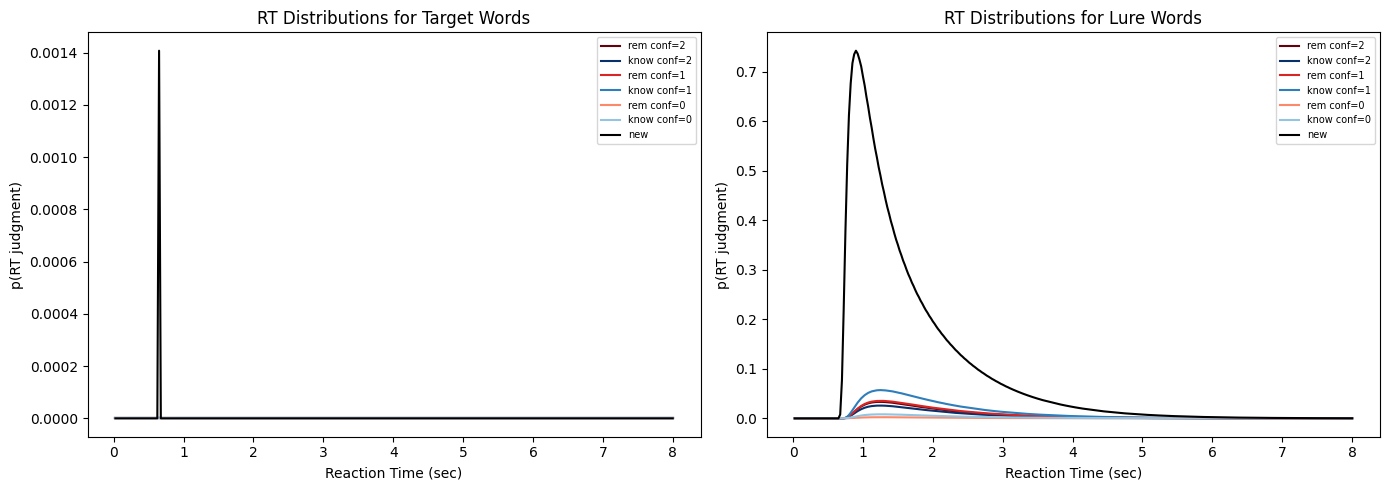

In [12]:
fig, axes = sisp_var_rbound_lure_model.plot_rt_distributions(params_est, show=False)

results = [
    sisp_var_rbound_lure_model.evaluate(params_est, method="qmpe", n_params=n_params, n_trials=n_trials),
    sisp_var_rbound_lure_model.evaluate(params_est, method="qmle", n_params=n_params, n_trials=n_trials),
    sisp_var_rbound_lure_model.evaluate(params_est, method="cml", n_params=n_params, n_trials=n_trials),
]

display_comparison(results)

### DISP Classic

In [15]:
class DISPClassicLuresOnly(DISPClassicDDM):
    Params = DISPClassicDDM.Params

    def compute_gof_all(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
        """Overrides the base loss function to ONLY compute loss for Lures."""
        try:
            target_params, lure_params = self.split_params(model_params)

            # Only extract the new (lure) data
            new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

            # Compute GOF ONLY for the lures
            gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

            if pl.isnan(gof_lure) or pl.isinf(gof_lure):
                return 1e9
            return gof_lure
        except Exception:
            return 1e9


disp_classic_lure_model = DISPClassicLuresOnly(
    config=caa_cfg,
    nr_threads=1,
)

original_bounds = disp_classic.param_bounds
locked_lower = original_bounds[0]
locked_upper = original_bounds[1]._replace(
    mu_r=locked_lower.mu_r,
    mu_f=locked_lower.mu_f,
)
param_bounds = (locked_lower, locked_upper)

n_params = 10
n_trials = (
    len(data.CR.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

# Optimize over entire data (Uncomment to run)
# disp_classic_lure_opt = fit_methods(
#     disp_classic_lure_model,
#     methods,
#     param_bounds=param_bounds,
#     nr_workers=7,
# )

disp_classic_lure_opt = {
    'qmle': DISPClassicLuresOnly.Params(c=np.float64(1.1963720644704954), mu_r=np.float64(-1.8992137285188053), mu_f=np.float64(-1.887565287403501), d_r=np.float64(0.07927202881002127), d_f=np.float64(0.3771286191232043), tc_bound=np.float64(0.02016365637072415), r_bound=np.float64(0.2339964811003736), z0=np.float64(-0.2524874346593893), mu_r_new=np.float64(-0.0759291906436331), mu_f_new=np.float64(-0.17191030090531512), t_post=np.float64(0.4395359900020719), t0=np.float64(0.6624999705139678)),
    'qmpe': DISPClassicLuresOnly.Params(c=np.float64(1.1737101114473565), mu_r=np.float64(-2.0288173751643255), mu_f=np.float64(-1.9561003226015687), d_r=np.float64(0.07467110265083027), d_f=np.float64(0.374441680060155), tc_bound=np.float64(0.022435133527800785), r_bound=np.float64(0.20617481650232322), z0=np.float64(-0.23427059243307974), mu_r_new=np.float64(-0.08569562407850152), mu_f_new=np.float64(-0.17989238655595258), t_post=np.float64(0.43891727730032215), t0=np.float64(0.6473058720106635))
}

method = "qmpe"
params_est = disp_classic_lure_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 3,886 | 3,886 | 3,886 |
| **Parameters ($k$)** | 10 | 10 | 10 |
| **Negative Log-Likelihood** | 160.56 | 172.04 | 8202.50 |
| **AIC** | **341.12** | **364.08** | **16425.00** |
| **BIC** | **403.77** | **426.73** | **16487.65** |


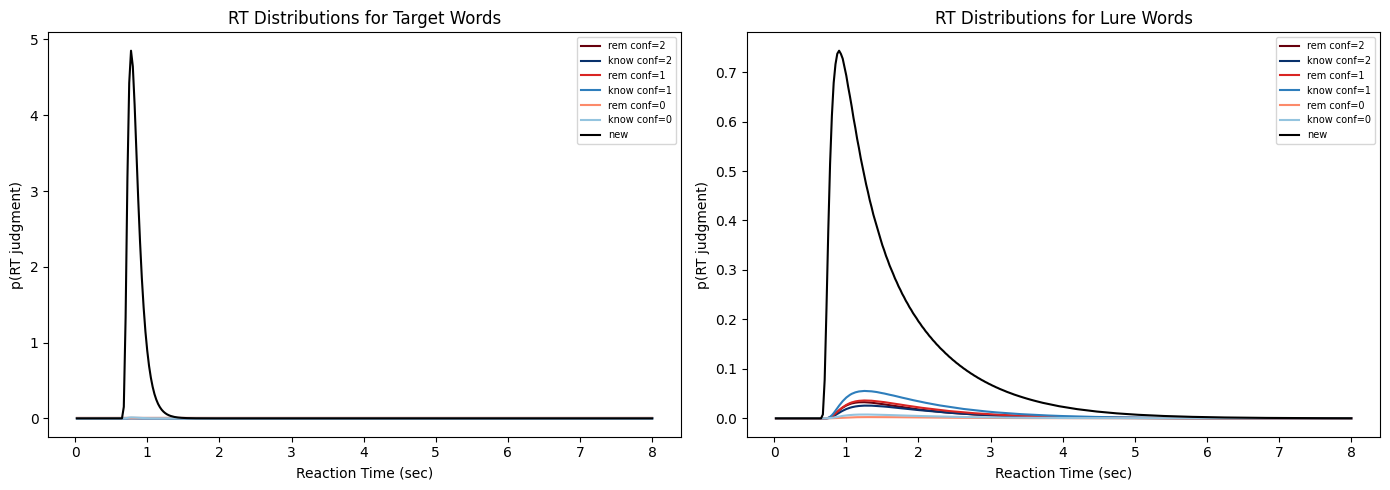

In [16]:
fig, axes = disp_classic_lure_model.plot_rt_distributions(params_est, show=False)
results = [
    disp_classic_lure_model.evaluate(params_est, method="qmpe", n_params=n_params, n_trials=n_trials),
    disp_classic_lure_model.evaluate(params_est, method="qmle", n_params=n_params, n_trials=n_trials),
    disp_classic_lure_model.evaluate(params_est, method="cml", n_params=n_params, n_trials=n_trials),
]

display_comparison(results)

### SISP Classic

In [23]:
class SISPclassicLuresOnly(SISPClassicDDM):
    Params = SISPClassicDDM.Params

    def compute_gof_all(self, model_params, data=base_model.DATA, method="qmpe", use_chisq=False):
        """Overrides the base loss function to ONLY compute loss for Lures."""
        try:
            target_params, lure_params = self.split_params(model_params)

            # Only extract the new (lure) data
            new_data = [data.rem_fa.rt, data.know_fa.rt, data.CR.rt, data.rem_fa.conf, data.know_fa.conf]

            # Compute GOF ONLY for the lures
            gof_lure = self.compute_model_gof(lure_params, *new_data, method=method, use_chisq=use_chisq)

            if pl.isnan(gof_lure) or pl.isinf(gof_lure):
                return 1e9
            return gof_lure
        except Exception:
            return 1e9


sisp_classic_lure_model = SISPclassicLuresOnly(
    config=caa_cfg,
    nr_threads=1,
)

original_bounds = sisp_classic.param_bounds
locked_lower = original_bounds[0]
locked_upper = original_bounds[1]._replace(
    mu_t=locked_lower.mu_t,
    z0_t=locked_lower.z0_t,
)
param_bounds = (locked_lower, locked_upper)

n_params = 8
n_trials = (
    len(data.CR.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

# Optimize over entire data
# sisp_classic_lure_opt = fit_methods(
#     sisp_classic_lure_model,
#     methods,
#     param_bounds=param_bounds,
#     nr_workers=7,
# )

# Nonnegative mu
sisp_classic_lure_opt = {
    'qmle': SISPclassicLuresOnly.Params(c=np.float64(1.549972892371577), mu_t=np.float64(0.00011188888867321833), mu_l=np.float64(0.0009036473403820572), d=np.float64(0.4159760420101952), tc_bound=np.float64(0.038689999160129135), r_bound_offset=np.float64(1.4652590382614434), z0_t=np.float64(-1.9972568542981275), z0_l=np.float64(-0.4365810311173086), t_post=np.float64(0.5902986903539058), t0=np.float64(0.7150708213250883)),
    'qmpe': SISPclassicLuresOnly.Params(c=np.float64(1.5929513561719015), mu_t=np.float64(-0.00019185927091752643), mu_l=np.float64(6.14552258337789e-05), d=np.float64(0.45194556406566005), tc_bound=np.float64(0.010718740897551211), r_bound_offset=np.float64(1.4910979942266325), z0_t=np.float64(-2.0206751502811713), z0_l=np.float64(-0.42602237659361086), t_post=np.float64(0.5470781636047688), t0=np.float64(0.7243959170301364))
}

# Negative mu
# sisp_classic_lure_opt = {
#     'qmle': SISPclassicLuresOnly.Params(c=np.float64(1.3774682194277856), mu_t=np.float64(-2.059914767618003), mu_l=np.float64(-0.31455263941317224), d=np.float64(0.4434492005635672), tc_bound=np.float64(0.01740067800969118), r_bound_offset=np.float64(1.1806949733660348), z0_t=np.float64(-2.089197751402779), z0_l=np.float64(-0.25840151340120543), t_post=np.float64(0.42314679474104777), t0=np.float64(0.6610030561060856)),
#     'qmpe': SISPclassicLuresOnly.Params(c=np.float64(1.3540270702661368), mu_t=np.float64(-2.145527311183932), mu_l=np.float64(-0.31826156956577684), d=np.float64(0.42976639249311854), tc_bound=np.float64(0.020987419945690134), r_bound_offset=np.float64(1.1589686283349265), z0_t=np.float64(-2.291721594026011), z0_l=np.float64(-0.2493619925556213), t_post=np.float64(0.4140192358038306), t0=np.float64(0.6487530546952779))
# }


method = "qmpe"
params_est = sisp_classic_lure_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 3,886 | 3,886 | 3,886 |
| **Parameters ($k$)** | 8 | 8 | 8 |
| **Negative Log-Likelihood** | 716.20 | 885.99 | 9025.09 |
| **AIC** | **1448.40** | **1787.99** | **18066.19** |
| **BIC** | **1498.52** | **1838.11** | **18116.31** |


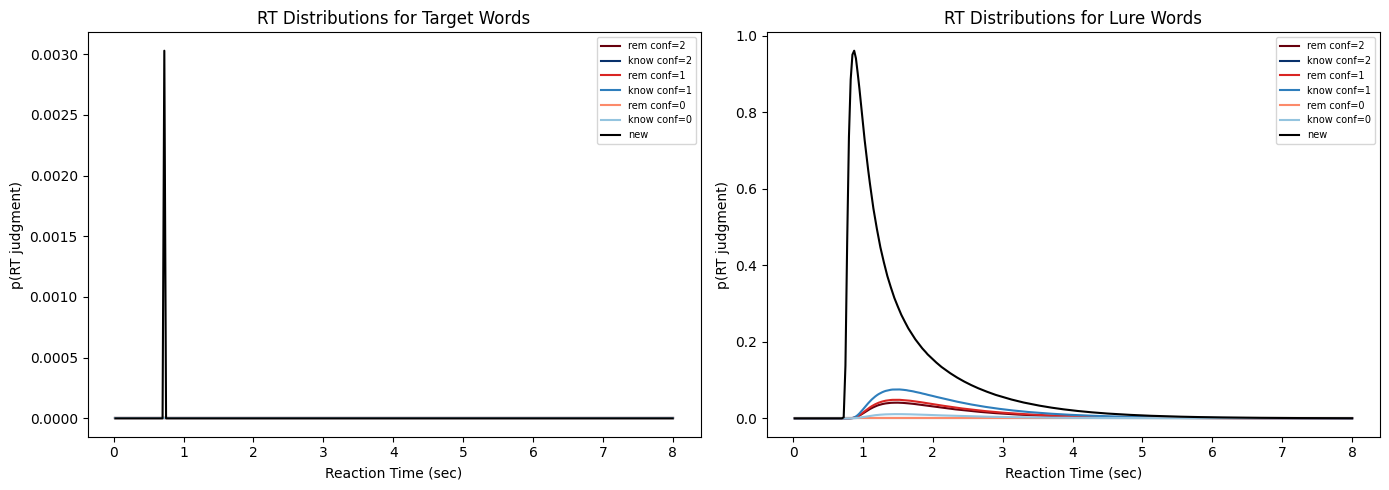

In [24]:
fig, axes = sisp_classic_lure_model.plot_rt_distributions(params_est, show=False)

results = [
    sisp_classic_lure_model.evaluate(params_est, method="qmpe", n_params=n_params, n_trials=n_trials),
    sisp_classic_lure_model.evaluate(params_est, method="qmle", n_params=n_params, n_trials=n_trials),
    sisp_classic_lure_model.evaluate(params_est, method="cml", n_params=n_params, n_trials=n_trials),
]

display_comparison(results)

### NLL Analysis

In [17]:
def _get_bin_probs(data_conf_array, total_n):
    """Helper to get empirical probabilities by confidence bin."""
    if len(data_conf_array) == 0:
        return {}
    unique_confs, counts = np.unique(data_conf_array, return_counts=True)
    return {int(conf): count / total_n for conf, count in zip(unique_confs, counts)}

def _get_bin_counts(data_conf_array):
    """Helper to map confidence arrays to bin counts (Conf 2, 1, 0)."""
    counts_dict = {0: 0, 1: 0, 2: 0}
    if len(data_conf_array) > 0:
        unique, counts = np.unique(data_conf_array, return_counts=True)
        for u, c in zip(unique, counts):
            counts_dict[int(u)] = c
    return [counts_dict[2], counts_dict[1], counts_dict[0]]

def _get_model_preds(model, params_est):
    """Helper to extract prediction arrays from a model."""
    _, lure_params = model.split_params(params_est)
    p_rem, p_know, p_new, _ = model.predicted_proportions(lure_params)
    return p_rem, p_know, p_new

def _get_penalty(count, prob, eps=1e-10):
    """Helper to calculate NLL penalty."""
    safe_p = max(prob, eps)
    return -count * np.log(safe_p)

def compare_models(model1, params1, name1, model2, params2, name2, data):
    """
    Compares two models against empirical Lure data, printing overall probabilities,
    confidence bin breakdowns, and NLL penalties.
    """
    # --- DATA PREP ---
    n_rem = len(data.rem_fa.rt)
    n_know = len(data.know_fa.rt)
    n_cr = len(data.CR.rt)
    n_total = n_rem + n_know + n_cr

    rem_counts = _get_bin_counts(data.rem_fa.conf)
    know_counts = _get_bin_counts(data.know_fa.conf)
    
    actual_rem_conf = _get_bin_probs(data.rem_fa.conf, n_total)
    actual_know_conf = _get_bin_probs(data.know_fa.conf, n_total)
    actual_cr_prob = n_cr / n_total

    # --- MODEL PREP ---
    m1_rem, m1_know, m1_new = _get_model_preds(model1, params1)
    m2_rem, m2_know, m2_new = _get_model_preds(model2, params2)

    # --- SECTION 1: OVERALL PROBABILITIES ---
    print("=" * 60)
    print(f"{'OVERALL PROBABILITIES (LURES)':^60}")
    print("=" * 60)
    print(f"{'Category':<20} | {'Human':<10} | {name1:<10} | {name2:<10}")
    print("-" * 60)
    print(f"{'Rem False Alarms':<20} | {n_rem/n_total:<10.3f} | {pl.sum(m1_rem):<10.3f} | {pl.sum(m2_rem):<10.3f}")
    print(f"{'Know False Alarms':<20} | {n_know/n_total:<10.3f} | {pl.sum(m1_know):<10.3f} | {pl.sum(m2_know):<10.3f}")
    print(f"{'Correct Rejects':<20} | {actual_cr_prob:<10.3f} | {pl.sum(m1_new):<10.3f} | {pl.sum(m2_new):<10.3f}\n")

    # --- SECTION 2: CONFIDENCE BINS ---
    m1_rem_conf = pl.sum(m1_rem, axis=1)
    m1_know_conf = pl.sum(m1_know, axis=1)
    m2_rem_conf = pl.sum(m2_rem, axis=1)
    m2_know_conf = pl.sum(m2_know, axis=1)

    print("=" * 75)
    print(f"{'PROBABILITIES BY CONFIDENCE BIN':^75}")
    print("=" * 75)
    print(f"{'Category':<22} | {'Human Actual':<15} | {name1:<15} | {name2:<15}")
    print("-" * 75)
    print(f"{'Correct Rejects':<22} | {actual_cr_prob:<15.4f} | {pl.sum(m1_new):<15.4f} | {pl.sum(m2_new):<15.4f}")

    for i in range(3):
        conf = 2 - i
        h_rem = actual_rem_conf.get(conf, 0.0)
        label = f"Rem Conf {conf} (Bin {i+1})"
        print(f"{label:<22} | {h_rem:<15.4f} | {m1_rem_conf[i]:<15.4f} | {m2_rem_conf[i]:<15.4f}")
        
    for i in range(3):
        conf = 2 - i
        h_know = actual_know_conf.get(conf, 0.0)
        label = f"Know Conf {conf} (Bin {i+1})"
        print(f"{label:<22} | {h_know:<15.4f} | {m1_know_conf[i]:<15.4f} | {m2_know_conf[i]:<15.4f}")
    print("\n")

    # --- SECTION 3: NLL PENALTIES ---
    print("=" * 82)
    print(f"{'PURE NLL PENALTY PER CATEGORY (Lower is Better)':^82}")
    print("=" * 82)
    print(f"{'Category':<15} | {'Trials':<8} | {name1:<14} | {name2:<14} | {f'{name2} Gain':<15}")
    print("-" * 82)

    # Correct Rejections
    m1_pen = _get_penalty(n_cr, pl.sum(m1_new))
    m2_pen = _get_penalty(n_cr, pl.sum(m2_new))
    print(f"{'Correct Rejects':<15} | {n_cr:<8} | {m1_pen:<14.1f} | {m2_pen:<14.1f} | {m1_pen - m2_pen:>+10.1f}")

    # Remember False Alarms
    for i in range(3):
        count = rem_counts[i]
        m1_pen = _get_penalty(count, m1_rem_conf[i])
        m2_pen = _get_penalty(count, m2_rem_conf[i])
        print(f"Rem Conf {2-i:<6} | {count:<8} | {m1_pen:<14.1f} | {m2_pen:<14.1f} | {m1_pen - m2_pen:>+10.1f}")

    # Know False Alarms
    for i in range(3):
        count = know_counts[i]
        m1_pen = _get_penalty(count, m1_know_conf[i])
        m2_pen = _get_penalty(count, m2_know_conf[i])
        print(f"Know Conf {2-i:<5} | {count:<8} | {m1_pen:<14.1f} | {m2_pen:<14.1f} | {m1_pen - m2_pen:>+10.1f}")
    
    # Totals
    total_m1_pen = _get_penalty(n_cr, pl.sum(m1_new)) + sum([_get_penalty(rem_counts[i], m1_rem_conf[i]) for i in range(3)]) + sum([_get_penalty(know_counts[i], m1_know_conf[i]) for i in range(3)])
    total_m2_pen = _get_penalty(n_cr, pl.sum(m2_new)) + sum([_get_penalty(rem_counts[i], m2_rem_conf[i]) for i in range(3)]) + sum([_get_penalty(know_counts[i], m2_know_conf[i]) for i in range(3)])
    
    print("-" * 82)
    print(f"{'TOTAL NLL':<15} | {n_total:<8} | {total_m1_pen:<14.1f} | {total_m2_pen:<14.1f} | {total_m1_pen - total_m2_pen:>+10.1f}")

In [18]:
compare_models(
    sisp_var_rbound_lure_model,
    sisp_var_rbound_lure_opt["qmle"],
    "SISP Var",
    disp_classic_lure_model,
    disp_classic_lure_opt["qmle"],
    "DISP Classic",
    base_model.DATA,
)

# compare_models(
#     sisp_classic_lure_model,
#     sisp_classic_lure_opt["qmpe"],
#     "SISP Classic",
#     disp_classic_lure_model,
#     disp_classic_lure_opt["qmpe"],
#     "DISP Classic",
#     base_model.DATA,
# )

               OVERALL PROBABILITIES (LURES)                
Category             | Human      | SISP Var   | DISP Classic
------------------------------------------------------------
Rem False Alarms     | 0.116      | 0.111      | 0.109     
Know False Alarms    | 0.149      | 0.141      | 0.142     
Correct Rejects      | 0.735      | 0.742      | 0.743     

                      PROBABILITIES BY CONFIDENCE BIN                      
Category               | Human Actual    | SISP Var        | DISP Classic   
---------------------------------------------------------------------------
Correct Rejects        | 0.7349          | 0.7424          | 0.7432         
Rem Conf 2 (Bin 1)     | 0.0502          | 0.0503          | 0.0469         
Rem Conf 1 (Bin 2)     | 0.0587          | 0.0570          | 0.0576         
Rem Conf 0 (Bin 3)     | 0.0072          | 0.0034          | 0.0044         
Know Conf 2 (Bin 1)    | 0.0422          | 0.0403          | 0.0409         
Know Conf 1 (Bin 2)  